# Backtest Results Visualization

Visualize backtest results from ClickHouse `backtest_results` table.

Shows per-rule/per-ticker distribution, return distribution, win rate by horizon, and signal timeline.

In [43]:
import os
from datetime import datetime
from zoneinfo import ZoneInfo

import clickhouse_connect
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

ET = ZoneInfo("America/New_York")

ch_client = clickhouse_connect.get_client(
    host="localhost",
    port=8123,
    username="default",
    password=os.getenv("CLICKHOUSE_PASSWORD", ""),
    database="jerry_trader",
)
print("CH connected")

CH connected


In [32]:
# --- Parameters ---
DATE = "2026-03-13"
RUN_ID = "2026-03-13_68ef213f"  # Set to specific run_id, or None to use latest

In [33]:
# Load results from CH
if RUN_ID:
    run_filter = f"AND run_id = '{RUN_ID}'"
else:
    run_filter = ""

query = f"""
    SELECT *
    FROM backtest_results FINAL
    WHERE date = '{DATE}' {run_filter}
    ORDER BY trigger_time_ns ASC
"""

result = ch_client.query(query)
columns = list(result.column_names)
df = pl.DataFrame({col: [row[i] for row in result.result_rows] for i, col in enumerate(columns)})

if len(df) == 0:
    print(f"No results found for date={DATE}")
else:
    print(f"{len(df)} signals, run_id: {df['run_id'].unique().to_list()}")
    print(f"Rules: {df['rule_id'].unique().to_list()}")
    print(f"Tickers: {len(df['ticker'].unique())} unique")
    df.head()

9 signals, run_id: ['2026-03-13_68ef213f']
Rules: ['premarket_momentum_v1']
Tickers: 6 unique


## 1. Overview Stats

In [34]:
horizon_cols = [c for c in df.columns if c.startswith("return_")]
horizons = [c.replace("return_", "") for c in horizon_cols]

print(f"Total signals: {len(df)}")
print(f"Unique tickers: {df['ticker'].n_unique()}")
print(f"Rules: {df['rule_id'].unique().to_list()}")
print(f"Avg slippage: {df['slippage_pct'].mean():.3%}")
print()

for h_col, h_label in zip(horizon_cols, horizons):
    vals = df[h_col].drop_nulls()
    if len(vals) == 0:
        continue
    wins = vals.filter(vals > 0)
    win_rate = len(wins) / len(vals)
    avg_ret = vals.mean()
    gross_wins = vals.filter(vals > 0).sum()
    gross_losses = abs(vals.filter(vals < 0).sum())
    pf = gross_wins / gross_losses if gross_losses > 0 else 0.0
    print(f"  {h_label:>4}: win={win_rate:.0%} avg_ret={avg_ret:+.2%} PF={pf:.2f} n={len(vals)}")

Total signals: 9
Unique tickers: 6
Rules: ['premarket_momentum_v1']
Avg slippage: -6.096%

   30s: win=22% avg_ret=-1.00% PF=0.12 n=9
    1m: win=44% avg_ret=-0.77% PF=0.20 n=9
    2m: win=33% avg_ret=+1.75% PF=1.88 n=9
    5m: win=33% avg_ret=-1.91% PF=0.25 n=9
   10m: win=44% avg_ret=-2.00% PF=0.40 n=9
   15m: win=44% avg_ret=-2.78% PF=0.25 n=9
   30m: win=33% avg_ret=-2.76% PF=0.40 n=9
   60m: win=33% avg_ret=-1.68% PF=0.69 n=9


## 2. Return Distribution by Horizon

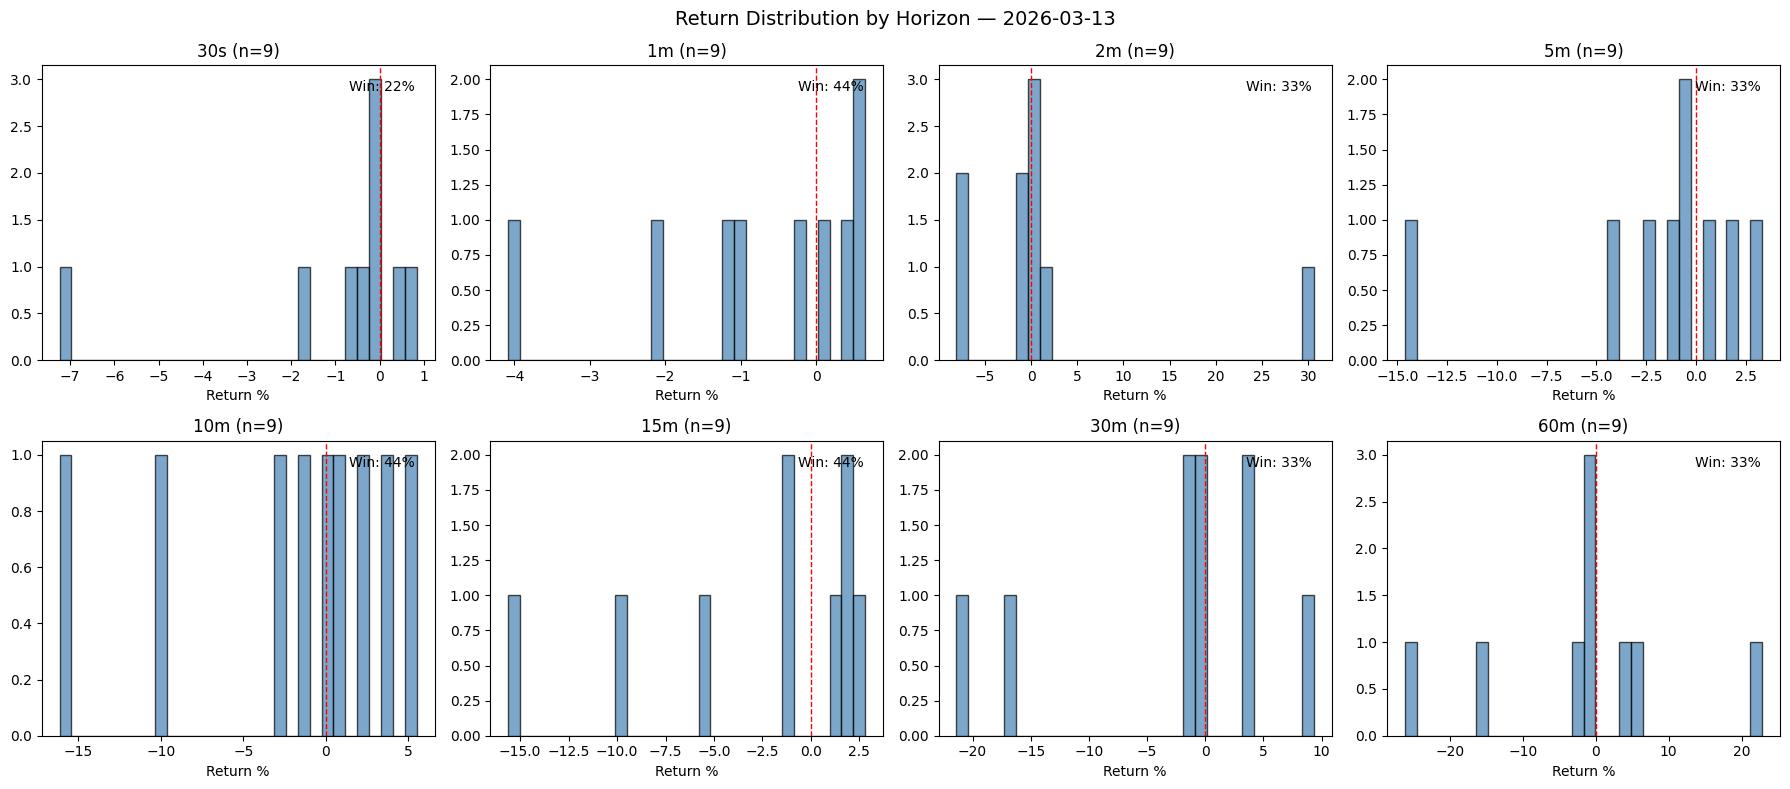

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(f"Return Distribution by Horizon — {DATE}", fontsize=14)

for ax, h_col, h_label in zip(axes.flat, horizon_cols, horizons):
    vals = df[h_col].drop_nulls().to_numpy() * 100  # to %
    if len(vals) == 0:
        ax.set_title(f"{h_label} (no data)")
        continue
    ax.hist(vals, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{h_label} (n={len(vals)})")
    ax.set_xlabel("Return %")
    win_pct = (vals > 0).sum() / len(vals) * 100
    ax.annotate(f"Win: {win_pct:.0f}%", xy=(0.95, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=10)

plt.tight_layout()
plt.show()

## 3. Win Rate & Avg Return by Horizon

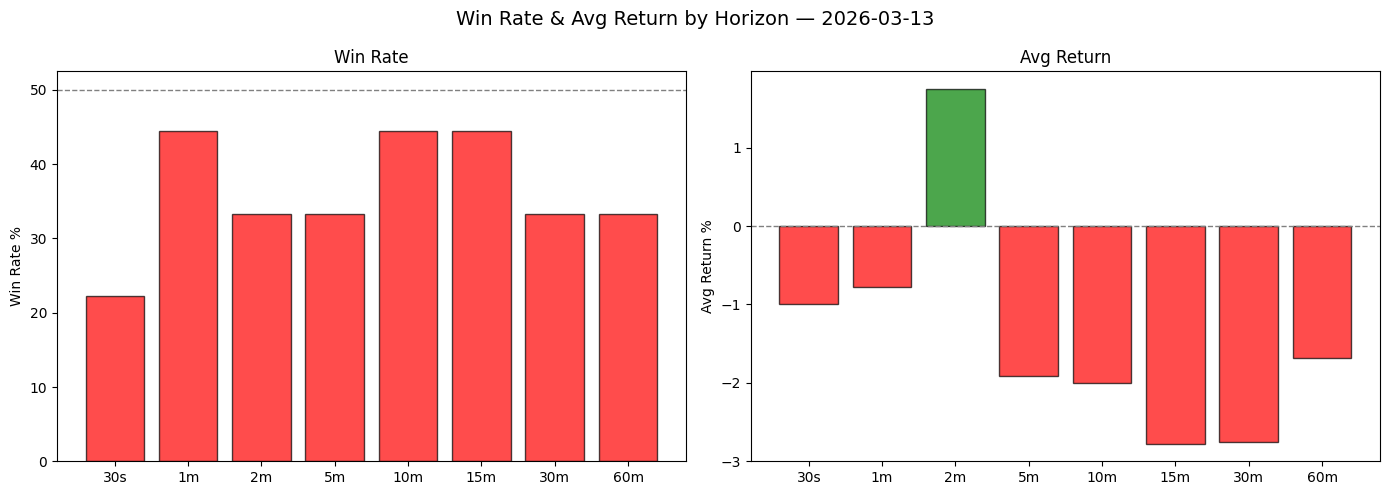

In [36]:
win_rates = []
avg_returns = []
valid_horizons = []

for h_col, h_label in zip(horizon_cols, horizons):
    vals = df[h_col].drop_nulls()
    if len(vals) == 0:
        continue
    valid_horizons.append(h_label)
    win_rates.append((vals > 0).sum() / len(vals) * 100)
    avg_returns.append(vals.mean() * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Win Rate & Avg Return by Horizon — {DATE}", fontsize=14)

colors = ["green" if r > 50 else "red" for r in win_rates]
ax1.bar(valid_horizons, win_rates, color=colors, alpha=0.7, edgecolor="black")
ax1.axhline(y=50, color="gray", linestyle="--", linewidth=1)
ax1.set_ylabel("Win Rate %")
ax1.set_title("Win Rate")

colors2 = ["green" if r > 0 else "red" for r in avg_returns]
ax2.bar(valid_horizons, avg_returns, color=colors2, alpha=0.7, edgecolor="black")
ax2.axhline(y=0, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Avg Return %")
ax2.set_title("Avg Return")

plt.tight_layout()
plt.show()

## 4. MFE vs MAE Scatter

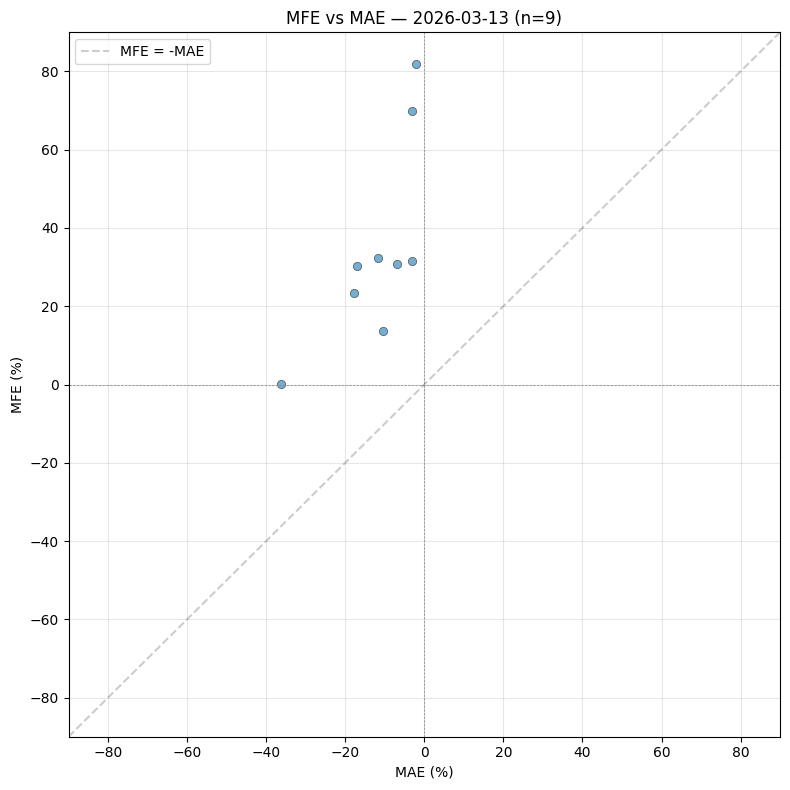

In [37]:
mfe = df["mfe"].drop_nulls().to_numpy() * 100
mae = df["mae"].drop_nulls().to_numpy() * 100

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(mae, mfe, alpha=0.6, edgecolors="black", linewidth=0.5)
ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("MAE (%)")
ax.set_ylabel("MFE (%)")
ax.set_title(f"MFE vs MAE — {DATE} (n={len(mfe)})")

# Diagonal reference: MFE = -MAE
lim = max(abs(mae.min()), abs(mae.max()), abs(mfe.min()), abs(mfe.max())) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.2, label="MFE = -MAE")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Signal Timeline

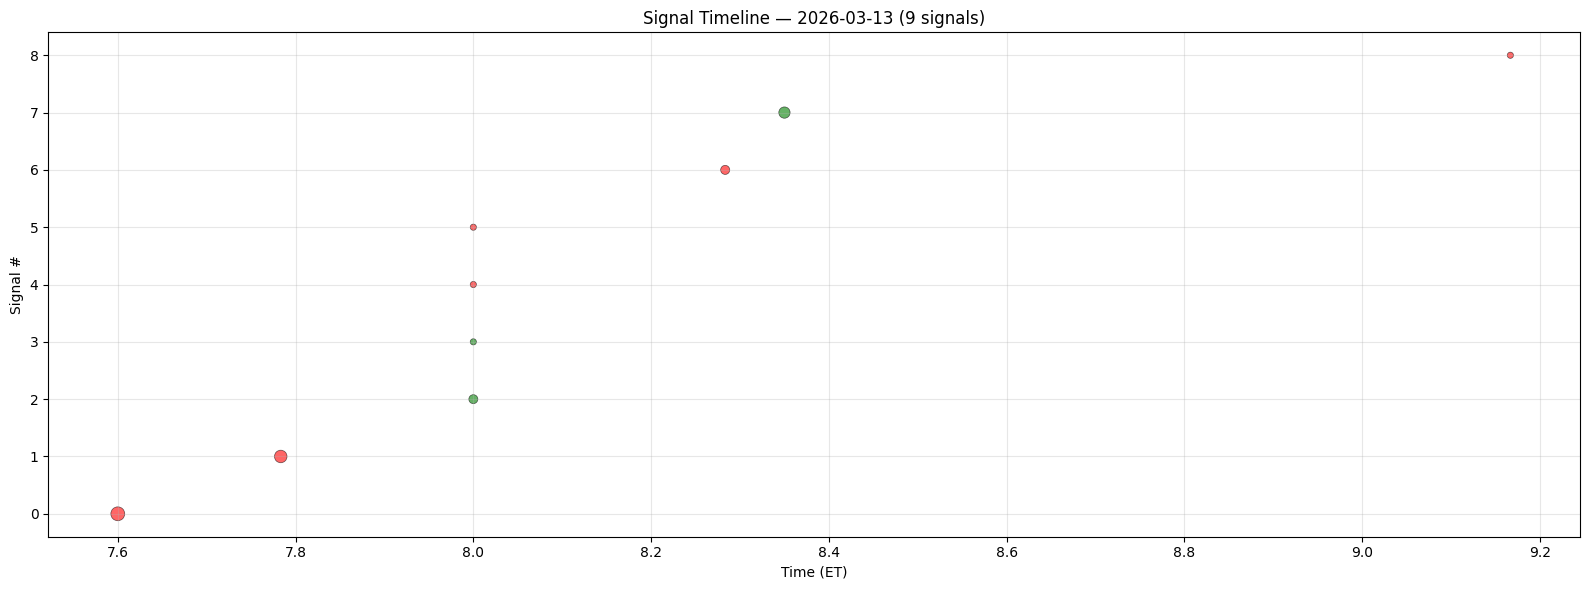

In [40]:
# Trigger times as ET hours for scatter
trigger_hours = [(t / 1e9 / 3600) % 24 for t in df["trigger_time_ns"].to_list()]
# Convert to actual ET hours from epoch
trigger_et = [datetime.fromtimestamp(t / 1e9, tz=ET) for t in df["trigger_time_ns"].to_list()]
trigger_h = [dt.hour + dt.minute / 60 for dt in trigger_et]

# Use 5m return for color if available, else first available
ret_col = "return_5m" if "return_5m" in horizon_cols else horizon_cols[0] if horizon_cols else None

fig, ax = plt.subplots(figsize=(16, 6))
if ret_col:
    rets = df[ret_col].fill_null(0).to_numpy() * 100
    colors = ["green" if r > 0 else "red" for r in rets]
    sizes = [max(20, min(100, abs(r) * 20)) for r in rets]
    ax.scatter(trigger_h, range(len(df)), c=colors, s=sizes, alpha=0.6, edgecolors="black", linewidth=0.5)
    ax.set_ylabel("Signal #")
else:
    ax.scatter(trigger_h, range(len(df)), alpha=0.5)
    ax.set_ylabel("Signal #")

ax.set_xlabel("Time (ET)")
ax.set_title(f"Signal Timeline — {DATE} ({len(df)} signals)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Per-Rule Breakdown

In [41]:
for rule_id in df["rule_id"].unique().to_list():
    rule_df = df.filter(pl.col("rule_id") == rule_id)
    print(f"\n=== Rule: {rule_id} ({len(rule_df)} signals) ===")
    print(f"  Tickers: {rule_df['ticker'].unique().to_list()}")
    print(f"  Avg slippage: {rule_df['slippage_pct'].mean():.3%}")
    mfe_avg = rule_df['mfe'].mean()
    mae_avg = rule_df['mae'].mean()
    if mfe_avg is not None:
        print(f"  Avg MFE: {mfe_avg:+.2%}  Avg MAE: {mae_avg:+.2%}")

    for h_col, h_label in zip(horizon_cols, horizons):
        vals = rule_df[h_col].drop_nulls()
        if len(vals) == 0:
            continue
        wins = (vals > 0).sum()
        win_pct = wins / len(vals) * 100
        avg = vals.mean() * 100
        print(f"  {h_label:>4}: win={win_pct:.0f}% avg={avg:+.2f}% n={len(vals)}")


=== Rule: premarket_momentum_v1 (9 signals) ===
  Tickers: ['EDHL', 'FRSX', 'PAYP', 'NIVF', 'KIDZ', 'BIAF']
  Avg slippage: -6.096%
  Avg MFE: +34.84%  Avg MAE: -12.03%
   30s: win=22% avg=-1.00% n=9
    1m: win=44% avg=-0.77% n=9
    2m: win=33% avg=+1.75% n=9
    5m: win=33% avg=-1.91% n=9
   10m: win=44% avg=-2.00% n=9
   15m: win=44% avg=-2.78% n=9
   30m: win=33% avg=-2.76% n=9
   60m: win=33% avg=-1.68% n=9


## 7. Top Tickers by Signal Count & Return

In [42]:
# Group by ticker
ret_col = "return_5m" if "return_5m" in horizon_cols else (horizon_cols[0] if horizon_cols else None)

ticker_stats = df.group_by("ticker").agg([
    pl.count().alias("n_signals"),
    pl.col("slippage_pct").mean().alias("avg_slippage"),
    pl.col("mfe").mean().alias("avg_mfe"),
    pl.col("mae").mean().alias("avg_mae"),
] + ([pl.col(ret_col).mean().alias("avg_return")] if ret_col else []))

ticker_stats = ticker_stats.sort("n_signals", descending=True)
print(f"Top 20 tickers by signal count:")
ticker_stats.head(20)

Top 20 tickers by signal count:


/tmp/ipykernel_76607/2662919672.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_signals"),


ticker,n_signals,avg_slippage,avg_mfe,avg_mae,avg_return
str,u32,f64,f64,f64,f64
"""EDHL""",2,-0.192081,0.758348,-0.025741,-0.013714
"""BIAF""",2,0.003749,0.2218,-0.086374,0.013564
"""KIDZ""",2,-0.044974,0.151567,-0.265876,-0.062593
"""NIVF""",1,-0.034854,0.314733,-0.031706,-0.009853
"""PAYP""",1,-0.054836,0.322641,-0.118081,0.004236
"""FRSX""",1,0.007696,0.234646,-0.176903,-0.040826
